<a href="https://colab.research.google.com/github/Abhinaytechie/LangGraph/blob/main/MemoryStore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install  langchain_groq langgraph langchain_core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.3/469.3 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.6/207.6 kB 4.7 MB/s eta 0:00:00
  Attempting uninstall: langchain_core
    Found existing installation: langchain-core 0.3.79
    Uninstalling langchain-core-0.3.79:
      Successfully uninstalled langchain-core-0.3.79
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.3.27 requires langchain-core<1.0.0,>=0.3.72, but you have langchain-core 1.0.2 which is incompatible.


In [ ]:
import uuid
from langgraph.store.memory import InMemoryStore
in_memory_store = InMemoryStore()


In [ ]:
user_id="1"
namespace_for_memory=(user_id,"memories")

key=str(uuid.uuid4())
value={"Food_preference":"I like biryani's"}

in_memory_store.put(namespace_for_memory,key,value)

In [ ]:
memories=in_memory_store.search(namespace_for_memory)
memories[0].dict()

{'namespace': ['1', 'memories'],
 'key': 'cce8362b-b5d5-4975-9937-e9949de83ed2',
 'value': {'Food_preference': "I like biryani's"},
 'created_at': '2025-11-03T04:19:42.316981+00:00',
 'updated_at': '2025-11-03T04:19:42.316986+00:00',
 'score': None}

In [ ]:
memory=in_memory_store.get(namespace_for_memory,key)
memory.dict()

{'namespace': ['1', 'memories'],
 'key': 'cce8362b-b5d5-4975-9937-e9949de83ed2',
 'value': {'Food_preference': "I like biryani's"},
 'created_at': '2025-11-03T04:19:42.316981+00:00',
 'updated_at': '2025-11-03T04:19:42.316986+00:00'}

In [ ]:
from langchain_groq import ChatGroq
from google.colab import userdata
llm =ChatGroq(groq_api_key=userdata.get('GROQ_API_KEY'),model="llama-3.3-70b-versatile")

In [ ]:
from IPython.display import Image,display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, START,END
from langgraph.store.base import BaseStore

from langchain_core.messages import HumanMessage,SystemMessage
from langchain_core.runnables.config import RunnableConfig
MODEL_SYSTEM_MESSAGE = """You are a helpful assistant with memory that provides information about the user.
If you have memory for this user, use it to personalize your responses.
Here is the memory (it may be empty): {memory}"""

# Create new memory from the chat history and any existing memory
CREATE_MEMORY_INSTRUCTION = """"You are collecting information about the user to personalize your responses.

CURRENT USER INFORMATION:
{memory}

INSTRUCTIONS:
1. Review the chat history below carefully
2. Identify new information about the user, such as:
   - Personal details (name, location)
   - Preferences (likes, dislikes)
   - Interests and hobbies
   - Past experiences
   - Goals or future plans
3. Merge any new information with existing memory
4. Format the memory as a clear, bulleted list
5. If new information conflicts with existing memory, keep the most recent version

Remember: Only include factual information directly stated by the user. Do not make assumptions or inferences.

Based on the chat history below, please update the user information:"""

def call_model(state: MessagesState, config: RunnableConfig, store: BaseStore):

   user_id=config['configurable']['user_id']
   namespace= ('memory',user_id)
   key='user_memory'
   existing_memory=store.get(namespace_for_memory,key)
   if existing_memory:
        # Value is a dictionary with a memory key
        existing_memory_content = existing_memory.value.get('memory')
   else:
      existing_memory_content = "No existing memory found."

  # Format the memory in the system prompt
   system_msg = MODEL_SYSTEM_MESSAGE.format(memory=existing_memory_content)

  # Respond using memory as well as the chat history
   response = llm.invoke([SystemMessage(content=system_msg)]+state["messages"])

   return {"messages": response}

def write_memory(state: MessagesState, config: RunnableConfig, store: BaseStore):
  user_id=config['configurable']['user_id']
  namespaces=("memory",user_id)

  key='user_memory'
  existing_memory=store.get(namespace_for_memory,key)
  if existing_memory:
    existing_memory_content=existing_memory.value.get('memory')
  else:
    existing_memory_content="No existing memory found."
  syst_msg=CREATE_MEMORY_INSTRUCTION.format(memory=existing_memory_content)
  new_memory=llm.invoke([SystemMessage(content=syst_msg)]+state["messages"])


  store.put(namespace_for_memory,key,{'memory':new_memory.content})



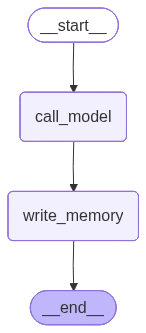

In [ ]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_node("write_memory", write_memory)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", "write_memory")
builder.add_edge("write_memory", END)

# Store for long-term (across-thread) memory
across_thread_memory = InMemoryStore()

# Checkpointer for short-term (within-thread) memory
within_thread_memory = MemorySaver()

# Compile the graph with the checkpointer fir and store
graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [ ]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory
config = {"configurable": {"thread_id": "1", "user_id": "1"}}

# User input
input_messages = [HumanMessage(content="Hi, my name is Lance")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Hi, my name is Lance
================================== Ai Message ==================================

Hello Lance, it's nice to meet you. I'll make a note of your name so I can address you personally in our conversation. Since we just started, I don't have any other information about you yet, but I'm excited to learn more and chat with you. What brings you here today?


In [ ]:
# User input
input_messages = [HumanMessage(content="I like to bike around San Francisco")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

I like to bike around San Francisco
================================== Ai Message ==================================

San Francisco is a beautiful city with a lot of great biking routes. I've made a note that you enjoy biking around San Francisco, Lance. If you don't mind me asking, do you have a favorite biking spot or trail in the city? Perhaps you like riding across the Golden Gate Bridge, or exploring the hills and neighborhoods like Haight-Ashbury or the Mission District?


In [ ]:
from langgraph.store.memory import InMemoryStore
memory_store=InMemoryStore()
user_id='2'
user_namespace=(user_id,"memory")
key='usermemo'
memory_store.put(user_namespace,key,{'memory':"I like to Like"})

In [ ]:
memory_store.get(user_namespace,key)

Item(namespace=['2', 'memory'], key='usermemo', value={'memory': 'I like to Like'}, created_at='2025-11-03T04:23:00.984818+00:00', updated_at='2025-11-03T04:23:00.984820+00:00')

In [ ]:
from pydantic import BaseModel,Field
